<a href="https://colab.research.google.com/github/rameelarustam47/Machine-Learning-Based-Flood-Risk-Mapping-Using-Geospatial-Data-Swat-Pakistan-/blob/main/Swat_flood_2025_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries ready!
Mounted at /content/drive
TIFF files loaded!
Total pixels: 3438927
Sampled pixels: 80000
Balanced dataset: (2530, 3)
MODEL ACCURACY
--------------------------
Logistic Regression: 0.8043
SVM                : 0.8162
Gradient Boosting  : 0.8142


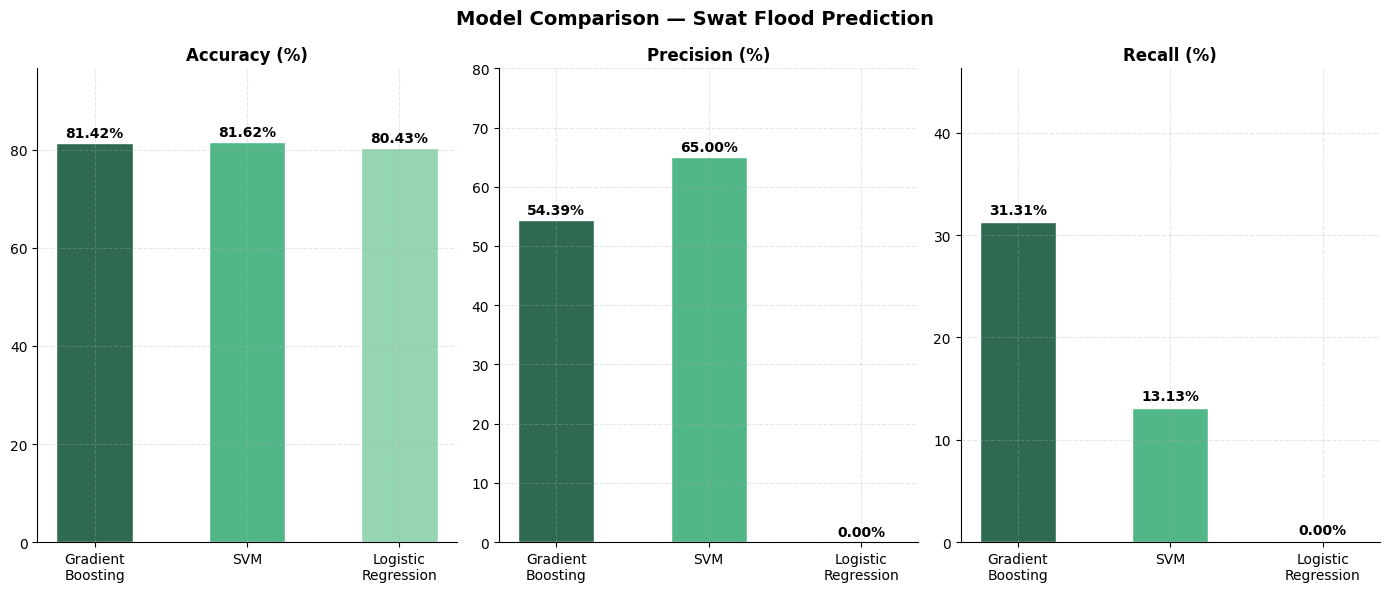

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏆 BEST MODEL: SVM


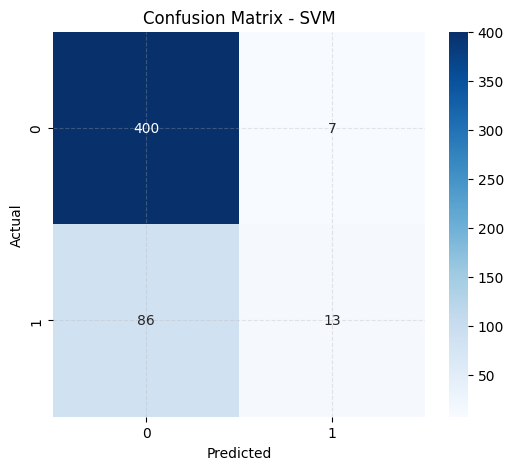

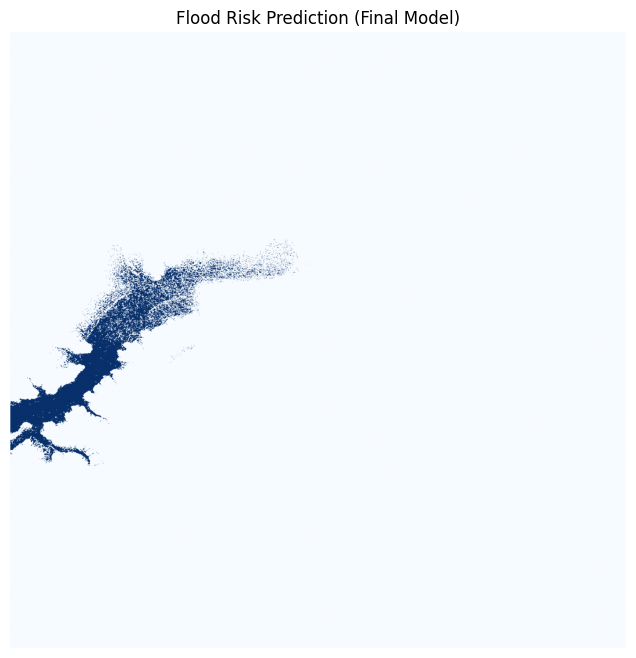


✅ FINAL PROJECT COMPLETE!


In [4]:
# ============================================
# SWAT FLOOD PREDICTION - FINAL IMPROVED MODEL
# ============================================

# STEP 1 - INSTALL & IMPORT
!pip install rasterio --quiet

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.transform import resize
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

print("Libraries ready!")

# STEP 2 - MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# STEP 3 - PATH
path = '/content/drive/MyDrive/swat_flood_2025/'

# STEP 4 - LOAD TIFF FILES
with rasterio.open(path + 'Swat_Flood_Extent_Fixed.tif') as src:
    flood_label = src.read(1).astype(float)

with rasterio.open(path + 'Swat_DEM_2025.tif') as src:
    dem = src.read(1).astype(float)

with rasterio.open(path + 'Swat_Slope_2025.tif') as src:
    slope = src.read(1).astype(float)

with rasterio.open(path + 'Swat_Rainfall_CHIRPS_2025.tif') as src:
    rainfall = src.read(1).astype(float)

print("TIFF files loaded!")

# STEP 5 - RESIZE
target = flood_label.shape
dem      = resize(dem, target)
slope    = resize(slope, target)
rainfall = resize(rainfall, target)

# STEP 6 - PREPARE DATA
X = np.column_stack([
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])

y = flood_label.flatten()

# Remove NaN
valid = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X[valid]
y = (y[valid] > 0.5).astype(int)

print("Total pixels:", X.shape[0])

# STEP 7 - RANDOM SAMPLING (INCREASED)
sample_size = 80000
idx = np.random.choice(len(X), sample_size, replace=False)

X = X[idx]
y = y[idx]

print("Sampled pixels:", X.shape[0])

# STEP 8 - BALANCE DATA (IMPROVED)
X_flood   = X[y==1]
y_flood   = y[y==1]

X_noflood = X[y==0]
y_noflood = y[y==0]

X_noflood, y_noflood = resample(
    X_noflood, y_noflood,
    n_samples=len(X_flood)*4,
    random_state=42
)

X = np.vstack([X_flood, X_noflood])
y = np.hstack([y_flood, y_noflood])

print("Balanced dataset:", X.shape)

# STEP 9 - TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 10 - MODELS
# ============================================

# 🔵 Logistic Regression
lr_model = LogisticRegression(max_iter=300)
lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)

# 🟣 SVM
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

# 🟢 Gradient Boosting (IMPROVED)
gb_model = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.03,
    max_depth=6
)
gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)

# ============================================
# STEP 11 - RESULTS
# ============================================


from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

acc_lr  = accuracy_score(y_test, pred_lr)
acc_svm = accuracy_score(y_test, pred_svm)
acc_gb  = accuracy_score(y_test, pred_gb)

print("MODEL ACCURACY")
print("--------------------------")
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"SVM                : {acc_svm:.4f}")
print(f"Gradient Boosting  : {acc_gb:.4f}")

r_gb  = classification_report(y_test, pred_gb,  output_dict=True)
r_svm = classification_report(y_test, pred_svm, output_dict=True)
r_lr  = classification_report(y_test, pred_lr,  output_dict=True)

accuracy  = [acc_gb*100,                 acc_svm*100,                 acc_lr*100]
precision = [r_gb['1']['precision']*100, r_svm['1']['precision']*100, r_lr['1']['precision']*100]
recall    = [r_gb['1']['recall']*100,    r_svm['1']['recall']*100,    r_lr['1']['recall']*100]

models = ['Gradient\nBoosting', 'SVM', 'Logistic\nRegression']
colors = ['#2D6A4F', '#52B788', '#95D5B2']

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Model Comparison — Swat Flood Prediction', fontsize=14, fontweight='bold')

for ax, title, vals in zip(axes, ['Accuracy (%)', 'Precision (%)', 'Recall (%)'], [accuracy, precision, recall]):
    bars = ax.bar(models, vals, color=colors, width=0.5, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) + 15)
    ax.set_title(title, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('model_comparison.png')


# ============================================
# STEP 12 - BEST MODEL
# ============================================

best_model = max([
    ('Logistic', acc_lr),
    ('SVM', acc_svm),
    ('GradientBoost', acc_gb)
], key=lambda x: x[1])

print(f"\n🏆 BEST MODEL: {best_model[0]}")

# ============================================
# STEP 13 - CONFUSION MATRIX
# ============================================

if best_model[0] == 'Logistic':
    cm = confusion_matrix(y_test, pred_lr)
elif best_model[0] == 'SVM':
    cm = confusion_matrix(y_test, pred_svm)
else:
    cm = confusion_matrix(y_test, pred_gb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model[0]}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================
# STEP 14 - FLOOD RISK MAP
# ============================================

X_all = np.column_stack([
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])

valid_all = np.isfinite(X_all).all(axis=1)
flood_map = np.zeros(X_all.shape[0])

if best_model[0] == 'Logistic':
    flood_map[valid_all] = lr_model.predict(X_all[valid_all])
elif best_model[0] == 'SVM':
    flood_map[valid_all] = svm_model.predict(X_all[valid_all])
else:
    flood_map[valid_all] = gb_model.predict(X_all[valid_all])

flood_map = flood_map.reshape(dem.shape)

plt.figure(figsize=(10,8))
plt.imshow(flood_map, cmap='Blues')
plt.title('Flood Risk Prediction (Final Model)')
plt.axis('off')
plt.show()

print("\n✅ FINAL PROJECT COMPLETE!")